# S9 — Predicción de Ventas 2026 con Spark MLlib
**Pipeline**: Parquet ventas → VectorAssembler → LinearRegression → Predicción

Objetivo: predecir qué producto tendrá más ventas en 2026 usando historial de ventas.

In [1]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import (
    col, month, year, dayofweek, count, sum as spark_sum,
    avg, when, lit, to_date, round as spark_round
)
from pyspark.sql.types import DoubleType
from pyspark.ml import Pipeline
from pyspark.ml.feature import VectorAssembler, StringIndexer, OneHotEncoder
from pyspark.ml.regression import LinearRegression
from pyspark.ml.evaluation import RegressionEvaluator

import pandas as pd
import matplotlib.pyplot as plt

spark = (
    SparkSession.builder
    .appName('CasaMarket-S9-ML')
    .config('spark.sql.shuffle.partitions', '4')
    .getOrCreate()
)
spark.sparkContext.setLogLevel('WARN')
print('Spark listo ✓')

Spark listo ✓


## 1. Cargar datos de ventas desde Parquet

In [2]:
PARQUET_PATH = '/home/jovyan/output/parquet/ventas/'

ventas = spark.read.parquet(PARQUET_PATH)
print(f'Total registros: {ventas.count():,}')
ventas.printSchema()
ventas.show(5)

Total registros: 30,372
root
 |-- fecha: string (nullable = true)
 |-- producto: string (nullable = true)
 |-- cod_producto: string (nullable = true)
 |-- cantidad: string (nullable = true)
 |-- precio_unitario: string (nullable = true)
 |-- total: string (nullable = true)
 |-- cliente: string (nullable = true)
 |-- ruc_cliente: string (nullable = true)
 |-- vendedor: string (nullable = true)
 |-- zona: string (nullable = true)
 |-- _doc_id: long (nullable = true)
 |-- _archivo: string (nullable = true)
 |-- _parseado_en: string (nullable = true)
 |-- procesado_ts: timestamp (nullable = false)
 |-- cantidad_num: double (nullable = true)
 |-- precio_num: double (nullable = true)
 |-- total_num: double (nullable = true)
 |-- fecha_dt: date (nullable = true)

+-----+--------+------------+--------+---------------+-----+-------+-----------+--------+----+-------+--------------------+--------------------+--------------------+------------+----------+---------+--------+
|fecha|producto|cod_prod

## 2. Feature Engineering — Agregaciones mensuales por producto

In [10]:
# Convertir fecha y extraer features temporales
df = (
    ventas
    .filter(col('producto').isNotNull() & col('fecha_dt').isNotNull())
    .withColumn('anio',   year(col('fecha_dt')).cast(DoubleType()))
    .withColumn('mes',    month(col('fecha_dt')).cast(DoubleType()))
    .withColumn('total_n', col('total_num').cast(DoubleType()))
    .withColumn('cantidad_n', col('cantidad_num').cast(DoubleType()))
)

# Agregar por producto + mes
agg = (
    df
    .groupBy('producto', 'anio', 'mes')
    .agg(
        count('*').alias('transacciones'),
        spark_sum('cantidad_n').alias('unidades'),
        spark_round(spark_sum('total_n'), 2).alias('ingresos'),
    )
    .filter(col('producto').isNotNull())
)

print(f'Combinaciones producto-mes: {agg.count():,}')
agg.orderBy(col('ingresos').desc()).show(10)

Combinaciones producto-mes: 62
+--------------------+------+---+-------------+--------+--------+
|            producto|  anio|mes|transacciones|unidades|ingresos|
+--------------------+------+---+-------------+--------+--------+
|       PEPSI 2000ML |2026.0|5.0|         1075|  1580.0| 27900.0|
|    ESCOCESA 2250ml |2026.0|5.0|          544|   854.0| 23472.0|
|PILSEN CALLAO 620...|2026.0|5.0|           72|   202.0| 14140.0|
|    ESCOCESA 1500ML |2026.0|5.0|          425|   714.0|13450.56|
|   PEPSI AZUL 355ML |2026.0|5.0|         1304|  1561.0| 9335.37|
|NECTARIN 1500 ML ...|2026.0|5.0|          372|   780.0|  6775.0|
|       PEPSI 750 ML |2026.0|5.0|          251|   659.0|  6288.0|
|    PAPEL ELITE DUO |2026.0|5.0|           97|   125.0|  5125.0|
| NECTARIN 1500 ML...|2026.0|5.0|          306|   718.0|  4665.0|
|CERVEZA PILSEN TR...|2026.0|5.0|           28|    64.0|  4480.0|
+--------------------+------+---+-------------+--------+--------+
only showing top 10 rows



## 3. Top 10 productos por ingresos históricos

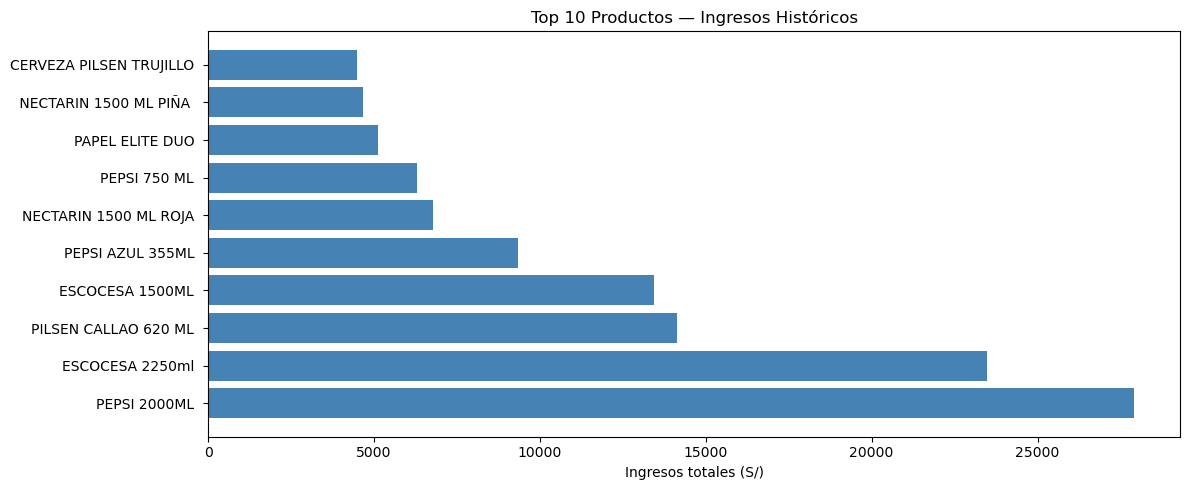

In [11]:
top_prod = (
    agg.groupBy('producto')
    .agg(spark_round(spark_sum('ingresos'), 2).alias('total_historico'))
    .orderBy(col('total_historico').desc())
    .limit(10)
    .toPandas()
)

fig, ax = plt.subplots(figsize=(12, 5))
ax.barh(top_prod['producto'], top_prod['total_historico'], color='steelblue')
ax.set_xlabel('Ingresos totales (S/)')
ax.set_title('Top 10 Productos — Ingresos Históricos')
plt.tight_layout()
plt.show()

## 4. Pipeline MLlib — Predicción de ingresos mensuales

In [12]:
# Encodificar 'producto' como número
indexer = StringIndexer(inputCol='producto', outputCol='producto_idx', handleInvalid='keep')

# Features: año, mes, producto codificado, transacciones históricas
assembler = VectorAssembler(
    inputCols=['anio', 'mes', 'producto_idx', 'transacciones', 'unidades'],
    outputCol='features'
)

lr = LinearRegression(
    featuresCol='features',
    labelCol='ingresos',
    maxIter=100,
    regParam=0.01,
)

pipeline = Pipeline(stages=[indexer, assembler, lr])

# Train / test split
train, test = agg.randomSplit([0.8, 0.2], seed=42)
print(f'Train: {train.count():,}  |  Test: {test.count():,}')

Train: 48  |  Test: 14


In [13]:
model = pipeline.fit(train)
predicciones = model.transform(test)

evaluator = RegressionEvaluator(labelCol='ingresos', predictionCol='prediction')

rmse = evaluator.evaluate(predicciones, {evaluator.metricName: 'rmse'})
mae  = evaluator.evaluate(predicciones, {evaluator.metricName: 'mae'})
r2   = evaluator.evaluate(predicciones, {evaluator.metricName: 'r2'})

print(f'RMSE : {rmse:,.2f}')
print(f'MAE  : {mae:,.2f}')
print(f'R²   : {r2:.4f}')

predicciones.select('producto', 'mes', 'anio', 'ingresos', 'prediction').show(10)

RMSE : 6,110.23
MAE  : 3,737.71
R²   : 0.3041
+--------------------+---+------+--------+------------------+
|            producto|mes|  anio|ingresos|        prediction|
+--------------------+---+------+--------+------------------+
| NECTARIN 1500 ML...|5.0|2026.0|  4665.0|5277.0301719987865|
|AGUA SAN CARLOS 3...|5.0|2026.0|  1015.0| 3209.661282367609|
|         ALOE FRESA |5.0|2026.0|  249.31|3219.4696800779143|
|               BIO  |5.0|2026.0|  1160.0|2989.1320949105966|
|CONCORDIA FRESA 3...|5.0|2026.0|  377.03|3809.0752826353155|
|    ESCOCESA 1500ML |5.0|2026.0|13450.56| 5247.163925062845|
|GATORADE COOL BLU...|5.0|2026.0|  1733.7| 5382.849803018877|
|    Galleta Jirafa  |5.0|2026.0|   339.2|  3102.89263444644|
|      PEPSI 1 LITRO |5.0|2026.0| 2968.17| 3615.899191191045|
|       PEPSI 2000ML |5.0|2026.0| 27900.0| 8127.346412171472|
+--------------------+---+------+--------+------------------+
only showing top 10 rows



## 5. Predicción 2026 — ¿Qué producto venderá más?

In [7]:
# Construir dataset futuro: todos los productos x cada mes de 2026
productos = agg.select('producto').distinct()
meses_2026 = spark.createDataFrame([(m,) for m in range(1, 13)], ['mes'])

# Promedio histórico de transacciones y unidades por producto
promedios = (
    agg.groupBy('producto')
    .agg(
        avg('transacciones').alias('transacciones'),
        avg('unidades').alias('unidades'),
    )
)

futuro = (
    productos
    .crossJoin(meses_2026)
    .join(promedios, 'producto', 'left')
    .withColumn('anio', lit(2026.0))
    .withColumn('mes',  col('mes').cast(DoubleType()))
    .withColumn('ingresos', lit(0.0))   # label placeholder
)

pred_2026 = model.transform(futuro)

top_2026 = (
    pred_2026
    .groupBy('producto')
    .agg(spark_round(spark_sum('prediction'), 2).alias('ingresos_predichos_2026'))
    .orderBy(col('ingresos_predichos_2026').desc())
    .limit(15)
    .toPandas()
)

print('=== TOP 15 PRODUCTOS PREDICHOS PARA 2026 ===')
print(top_2026.to_string(index=False))

=== TOP 15 PRODUCTOS PREDICHOS PARA 2026 ===
                 producto  ingresos_predichos_2026
            PEPSI 2000ML                  97528.16
        PEPSI AZUL 355ML                  89366.63
   CONCORDIA NARANJA 355                  78321.01
GATORADE COOL BLUE 500ML                  64594.20
  NECTARIN 1500 ML PIÑA                   63324.36
         ESCOCESA 1500ML                  62965.97
            PEPSI 750 ML                  60987.12
 GATORADE TROPICAL 500ML                  57618.51
    NECTARIN 600 ML ROJA                  55914.19
   NECTARIN 1500 ML ROJA                  53855.29
      PEPSI BLACK 355 ML                  53190.71
          LIMONADA MISTI                  50183.03
  AGUA SAN CARLOS 750 ML                  49836.23
             PEPSI 600ML                  49448.41
         ESCOCESA 2250ml                  47509.90


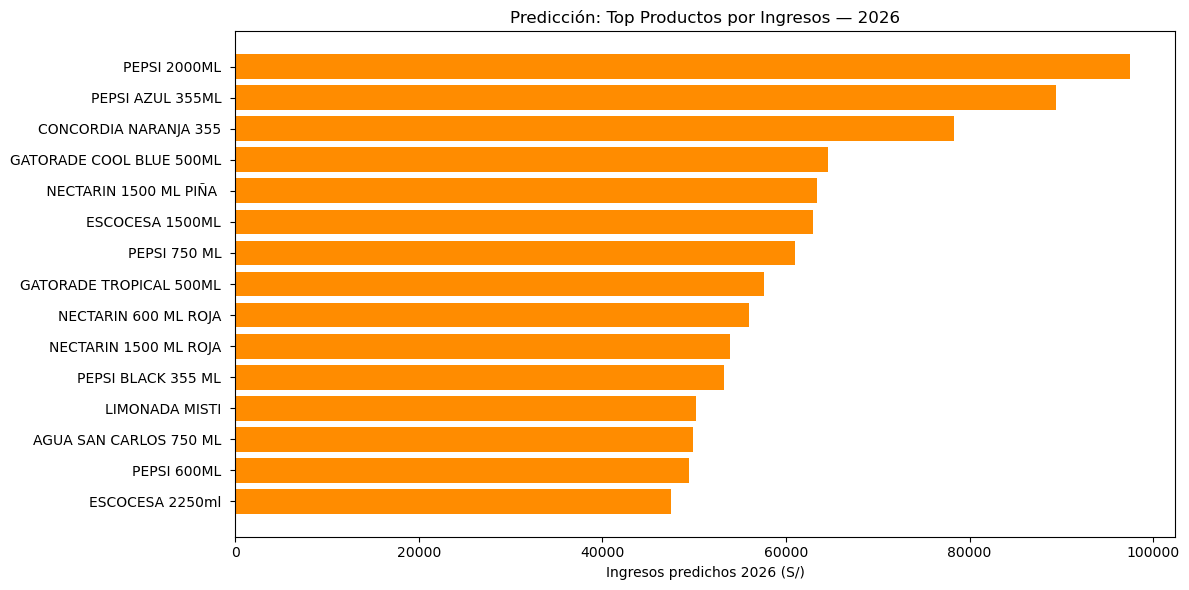

Gráfico guardado → output/prediccion_2026.png


In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
ax.barh(top_2026['producto'], top_2026['ingresos_predichos_2026'], color='darkorange')
ax.set_xlabel('Ingresos predichos 2026 (S/)')
ax.set_title('Predicción: Top Productos por Ingresos — 2026')
ax.invert_yaxis()
plt.tight_layout()
plt.savefig('/home/jovyan/output/prediccion_2026.png', dpi=150)
plt.show()
print('Gráfico guardado → output/prediccion_2026.png')

## 6. Guardar modelo

In [9]:
MODEL_PATH = '/home/jovyan/output/modelo_ventas_2026'
model.write().overwrite().save(MODEL_PATH)
print(f'Modelo guardado en {MODEL_PATH}')

# Para cargarlo:
# from pyspark.ml import PipelineModel
# model = PipelineModel.load(MODEL_PATH)

Modelo guardado en /home/jovyan/output/modelo_ventas_2026
